In [11]:
import pandas as pd
import numpy as np
import pyreadr
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
load = pyreadr.read_r("c:\\Users\\Maxim\\dsi-capstone-fall-2024-team-forecasting-treasury-yield\\Data\\cleaned_monthly_data.RData")

In [4]:
class ThresholdDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features  # Shape: (num_samples, num_features)
        self.labels = labels  # Shape: (num_samples,)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {
            'features': torch.tensor(self.features[idx], dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32)
        }

In [5]:
class ThresholdNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ThresholdNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = torch.sigmoid(self.fc2(x))
        return x

In [6]:
monthly_1985 = load['monthly_1985']
monthly_1985['yield_5yr_ahead'] = monthly_1985['tenyr_yield'].shift(-60)
monthly_1985 = monthly_1985.dropna()

y = monthly_1985[['month', 'yield_5yr_ahead']]
features = monthly_1985.drop(columns=['yield_5yr_ahead'])

In [7]:
features_cols = ["GDP_based_recession_indicator", "umich_inflation_excpectation", "industrial_production_consumer_goods",
                  "equity_market_volatility", "yen_dollar_exchange_rate", "producer_price_index_construction_materials",
                  "10yr_expected_inflation", "30yr_yield", "velocity_of_m1_money_stock", "yield_stdev", 'tenyr_yield', 'month']

features = features[features_cols]

In [8]:
percentiles = np.linspace(0.05, 0.95, 40)

labels = [] 
test_values = [] 
for i in range(len(y)): 
    y_value = y["yield_5yr_ahead"][i] 
    percentiles_values = np.percentile(y["yield_5yr_ahead"], percentiles * 100).reshape(-1, 1) 
    test_val_range = y_value + percentiles_values - np.median(percentiles_values)
    labels.append((y_value > test_val_range).astype(int)) 
    test_values.append(test_val_range)

In [9]:
def create_sliding_window(data, labels, thresholds, window_size, y):
    train_windows = []
    train_thresholds = []
    train_labels = []
    valid_data = []
    y_val = []
    
    
    try:
        data = data.drop(columns=["month"])
    except:
        raise Exception("No month column found")

    for i in range(len(data) - window_size - 60):
        train_windows.append(data[i:i+window_size])
        train_thresholds.append(thresholds[i:i+window_size])
        train_labels.append(labels[i:i+window_size])
        valid_data.append(data[window_size+60+i:window_size+61+i])
        y_val.append(y['yield_5yr_ahead'][window_size+60+i])

    
    return np.array(train_windows), np.array(train_labels), np.array(train_thresholds), np.array(valid_data), np.array(y_val)

In [12]:
def transform_data(windows, train_thresholds, y_train, val_data, val_thresholds, val_true):
    final_data = []

    for window, threshold, val, labels, y_val in zip(windows, train_thresholds, val_data, y_train, val_true):
        temp = np.repeat(window, repeats=40, axis=0)
        threshold = [item[0] for sublist in threshold for item in sublist]
        X_train = np.column_stack((temp, threshold))
        labels = [item[0] for sublist in labels for item in sublist]
        

        val = np.repeat(val, repeats=40, axis=0)
        test_values_val = percentiles_values
        X_val = np.column_stack((val, test_values_val))
        val_label = (y_val > test_values_val).astype(int)


        #TRY MINMAXSCALER
        scaler = MinMaxScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        dictionary = {"X_train": X_train_scaled, "y_train": labels, "X_val": X_val_scaled, "y_val": val_label}

        final_data.append(dictionary)

    return np.array(final_data)

In [13]:
training_window, train_labels, train_thresholds, val_data, y_val = create_sliding_window(features, labels, test_values, 60, y)

In [14]:
final_data = transform_data(training_window, train_thresholds, train_labels, val_data, percentiles_values, y_val)

In [15]:
train_loaders = []
val_loaders = []

for window in final_data:
    train_ds = ThresholdDataset(window["X_train"], window["y_train"])
    val_ds = ThresholdDataset(window["X_val"], window["y_val"])

    train_dl = DataLoader(train_ds, batch_size=32, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

    train_loaders.append(train_dl)
    val_loaders.append(val_dl)

In [16]:
device = 'cuda'

In [17]:
num_epochs = 1
large_window_size = 125
small_window_size = 120

predictions_array = []
expected_value_array = []
actual_value_array = []


for large_start in range(0, len(train_loaders) - large_window_size + 1):
    large_end = large_start + large_window_size

    print(f"Processing large window: {large_start}:{large_end}")

    #Initialize new model for large window
    model = ThresholdNN(final_data[0]["X_train"].shape[1], 32, 1).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr = 0.0001)

    for epoch in range(num_epochs):
        train_loss = 0.0
        val_loss = 0.0
        test_loss = 0.0

        
        for small_start in range(large_start, large_end - small_window_size + 1):
            small_end = small_start + small_window_size
            print(f"Training on small window: {small_start}:{small_end}")


            model.train()
            for data_loader in train_loaders[small_start:small_end]:
                for batch in data_loader:
                    features = batch['features'].to(device)
                    labels = batch['label'].to(device)

                    optimizer.zero_grad()
                    preds = model(features)
                    loss = criterion(preds.squeeze(1), labels)
                    train_loss += loss.item()
                    loss.backward()
                    optimizer.step()
            
            if small_end == large_end:
                small_end -= 1
            #model.eval()
            #with torch.no_grad():
            #    for data_loader in val_loaders[small_start:small_end]:
            #        for batch in data_loader:
            #            val_features = batch['features'].to(device)
            #            val_labels = batch['label'].to(device)
            #            predictions = model(val_features)
            #            loss = criterion(predictions, val_labels)
            #            val_loss += loss.item()
        
        preds = np.array([])
        
        model.eval()
        with torch.no_grad():
            for batch in val_loaders[small_end+1]:
                test_features = batch['features'].to(device)
                test_labels = batch['label'].to(device)
                predictions = model(test_features)
                preds = np.append(preds, predictions.cpu().numpy())
                loss = criterion(predictions, test_labels)
                test_loss += loss.item()
        #print(preds)


        num_train_batches = sum(len(dl) for dl in train_loaders[large_start:large_end - small_window_size + 1])
        #num_val_batches = sum(len(dl) for dl in val_loaders[large_start:large_end - small_window_size])
        num_test_batches = sum(len(dl) for dl in val_loaders[small_end:small_end+1])  


        print(f"Epoch {epoch + 1}: Train Loss: {train_loss / num_train_batches:.4f}, "
              #f"Val Loss: {val_loss / num_val_batches:.4f}, "
              f"Test Loss: {test_loss / num_test_batches:.4f}")

    #print(preds)     

    thresholds = [item for sublist in percentiles_values for item in sublist]
    num_samples = 1000
    uniform_samples = np.random.uniform(0, 1, size=num_samples)
    predicted_values = np.interp(uniform_samples, preds[::-1], thresholds[::-1])
    expected_value = np.mean(predicted_values)

    actual_value = y["yield_5yr_ahead"][120+small_end+1]

    print(f"Expected Value: {expected_value}, Actual Value: {actual_value}")

    predictions_array.append(preds)
    expected_value_array.append(expected_value)
    actual_value_array.append(actual_value)

Processing large window: 0:125
Training on small window: 0:120
Training on small window: 1:121
Training on small window: 2:122
Training on small window: 3:123
Training on small window: 4:124
Training on small window: 5:125
Epoch 1: Train Loss: 34.7212, Test Loss: 0.0662
Expected Value: 3.301856433435857, Actual Value: 3.2030000000000003
Processing large window: 1:126
Training on small window: 1:121
Training on small window: 2:122
Training on small window: 3:123
Training on small window: 4:124
Training on small window: 5:125
Training on small window: 6:126
Epoch 1: Train Loss: 34.1262, Test Loss: 0.0696
Expected Value: 3.1515791768231645, Actual Value: 3.009032258064516
Processing large window: 2:127
Training on small window: 2:122
Training on small window: 3:123
Training on small window: 4:124
Training on small window: 5:125
Training on small window: 6:126
Training on small window: 7:127
Epoch 1: Train Loss: 33.4763, Test Loss: 0.1271
Expected Value: 3.3648294518914454, Actual Value: 2

KeyboardInterrupt: 

In [21]:
# Convert lists to NumPy arrays
y_true_np = np.array(actual_value_array)
y_pred_np = np.array(expected_value_array)

# Calculate RMSE
rmse = np.sqrt(np.mean((y_true_np - y_pred_np) ** 2))

print(f'RMSE: {rmse:.4f}')

RMSE: 1.4191


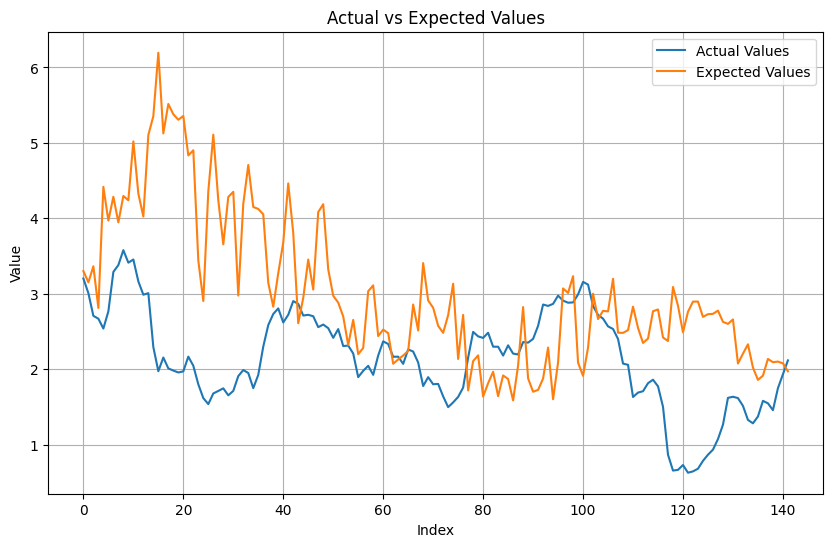

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 
plt.plot(actual_value_array, label='Actual Values') 
plt.plot(expected_value_array, label='Expected Values') 
plt.xlabel('Index') 
plt.ylabel('Value') 
plt.title('Actual vs Expected Values') 
plt.legend() 
plt.grid(True)
plt.show()

In [ ]:
current_preds = predictions_array

current_expected_values = expected_value_array

current_target = actual_value_array

In [18]:
def calculate_mape(actuals, predictions):
    actuals = np.array(actuals)
    predictions = np.array(predictions)
    
    # Avoid division by zero by replacing 0 values with a small epsilon
    epsilon = 1e-10
    actuals = np.where(actuals == 0, epsilon, actuals)
    
    # Calculate MAPE
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    return mape

In [20]:
calculate_mape(actual_value_array, expected_value_array)

66.41556801899972

In [384]:
y["yield_5yr_ahead"][119+1]

6.6493548387096775

In [ ]:
num_epochs = 2
large_window_size = 120
small_window_size = 60


for i in range(5, 60): #len(train_loaders)):
    model = ThresholdNN(final_data[0]["X_train"].shape[1], 16, 1)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr = 0.001)
    for epoch in range(num_epochs):
        train_loss = 0.0
        val_loss = 0.0
        test_loss = 0.0
        for j in range(i-5, i):
            print(f"timestep: {j}")
            
            model.train()
            for batch in train_loaders[j]:
                features = batch['features']
                labels = batch['label']

                optimizer.zero_grad()

                preds = model.forward(features)

                loss = criterion(preds.squeeze(1), labels)

                train_loss += loss.item()

                loss.backward()
                optimizer.step()

            if j != i-1:
                model.eval()
                with torch.no_grad():
                    for batch in val_loaders[j]:
                        val_features = batch['features']
                        val_labels = batch['label']

                        predictions = model.forward(val_features)
                        loss = criterion(predictions.squeeze(1), val_labels.squeeze(1))
                        val_loss += loss.item()

            else:
                model.eval()
                with torch.no_grad():
                    for batch in val_loaders[j]:
                        test_features = batch['features']
                        test_labels = batch['label']

                        predictions = model.forward(test_features)
                        loss = criterion(predictions.squeeze(1), test_labels.squeeze(1))
                        test_loss += loss.item()


        print(f"Epoch {epoch}. Train loss: {train_loss/(len(train_loaders[0]) * 5)}   Val Loss: {val_loss/(len(val_loaders[0]) * 4)}  Test Loss: {test_loss/(len(val_loaders[0]))}")
                    


timestep: 0
timestep: 1
timestep: 2
timestep: 3
timestep: 4
Epoch 0. Train loss: 0.5801830303569635   Val Loss: 0.46681971320261556  Test Loss: 0.346596025240918
timestep: 0
timestep: 1
timestep: 2
timestep: 3
timestep: 4
Epoch 1. Train loss: 0.2547343971307079   Val Loss: 0.21106322022387758  Test Loss: 0.17575930575064072
timestep: 0
timestep: 1
timestep: 2
timestep: 3
timestep: 4
Epoch 2. Train loss: 0.1675524867142861   Val Loss: 0.15257797373730378  Test Loss: 0.12056900322932051
timestep: 1
timestep: 2
timestep: 3
timestep: 4
timestep: 5
Epoch 0. Train loss: 0.5363584591249625   Val Loss: 0.4850156207879384  Test Loss: 0.25563719992836315
timestep: 1
timestep: 2
timestep: 3
timestep: 4
timestep: 5
Epoch 1. Train loss: 0.2302403342053294   Val Loss: 0.1943072935876747  Test Loss: 0.14030402239101628
timestep: 1
timestep: 2
timestep: 3
timestep: 4
timestep: 5
Epoch 2. Train loss: 0.16642500365618618   Val Loss: 0.21703171567060053  Test Loss: 0.11321362288435921
timestep: 2
timeste

KeyboardInterrupt: 

In [542]:
#first 5 years

X_train = np.repeat(features.drop(columns=["month"]).iloc[0:60].to_numpy(), repeats=40, axis=0)
flat_thresholds = [item[0] for sublist in test_values[0:60] for item in sublist]
X_train = np.column_stack((X_train, flat_thresholds))
y_train = [item[0] for sublist in labels[0:60] for item in sublist]

X_val = np.repeat(features.drop(columns=["month"])[120:121].to_numpy(), repeats=40, axis=0)
test_values_val = percentiles_values
X_val = np.column_stack((X_val, test_values_val))
y_val = (y["yield_5yr_ahead"][120] > test_values_val).astype(int)


#Scale data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [551]:
train_ds = ThresholdDataset(X_train_scaled, y_train)
val_ds = ThresholdDataset(X_val_scaled, y_val)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=False)
val_dl = DataLoader(val_ds, batch_size=16, shuffle=False)

In [566]:
model = ThresholdNN(X_train.shape[1], 16, 1)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

In [567]:
num_epochs = 75

for epoch in range(num_epochs):
    model.train()

    train_loss = 0.0

    for batch in train_dl:
        features = batch['features']
        labels = batch['label']

        optimizer.zero_grad()

        preds = model.forward(features)

        loss = criterion(preds.squeeze(1), labels)

        train_loss += loss.item()

        loss.backward()
        optimizer.step()

    val_loss = 0.0
    model.eval()
    with torch.no_grad():
        for batch in val_dl:
            val_features = batch['features']
            val_labels = batch['label']

            predictions = model.forward(val_features)
            loss = criterion(predictions.squeeze(1), val_labels.squeeze(1))
            val_loss += loss.item()

    print(f"Epoch {epoch}. Train loss: {train_loss/(len(train_dl))}   Val Loss: {val_loss/(len(val_dl))}")




Epoch 0. Train loss: 0.6641198817888896   Val Loss: 0.6447812716166178
Epoch 1. Train loss: 0.6595955022176107   Val Loss: 0.6364005406697592
Epoch 2. Train loss: 0.6549088029066722   Val Loss: 0.6278937458992004
Epoch 3. Train loss: 0.6500260212024053   Val Loss: 0.619166354338328
Epoch 4. Train loss: 0.6449271470308304   Val Loss: 0.6103117068608602
Epoch 5. Train loss: 0.6395764609177907   Val Loss: 0.6012559533119202
Epoch 6. Train loss: 0.6339293328921   Val Loss: 0.592012345790863
Epoch 7. Train loss: 0.6279626834392548   Val Loss: 0.5825290679931641
Epoch 8. Train loss: 0.6216386429468791   Val Loss: 0.5728826324144999
Epoch 9. Train loss: 0.6149501252174377   Val Loss: 0.5630814035733541
Epoch 10. Train loss: 0.6078953705231349   Val Loss: 0.5531420509020487
Epoch 11. Train loss: 0.6004616673787435   Val Loss: 0.5432059665520986
Epoch 12. Train loss: 0.5926500868797302   Val Loss: 0.5330929458141327
Epoch 13. Train loss: 0.5844249963760376   Val Loss: 0.5228961110115051
Epoch 1

In [568]:
preds = np.array([])
thresholds = np.array([])

model.eval()
test_loss = 0.0
with torch.no_grad():
    for batch in val_dl:
        val_features = batch['features']
        val_labels = batch['label']

        predictions = model.forward(val_features)
        for prediction, label in zip(predictions.numpy(),val_labels.numpy()):
            print(f"prediction: {prediction}")
            print(f"True value: {label}")

        preds = np.append(preds, predictions.numpy())

        loss = criterion(predictions.squeeze(1), val_labels.squeeze(1))
        test_loss += loss.item()

print(f"Test Loss: {test_loss/(len(val_dl) )}")

prediction: [0.99596405]
True value: [1.]
prediction: [0.9955837]
True value: [1.]
prediction: [0.995082]
True value: [1.]
prediction: [0.99430496]
True value: [1.]
prediction: [0.9938538]
True value: [1.]
prediction: [0.9928007]
True value: [1.]
prediction: [0.99207777]
True value: [1.]
prediction: [0.9912212]
True value: [1.]
prediction: [0.98991674]
True value: [1.]
prediction: [0.98891336]
True value: [1.]
prediction: [0.9871126]
True value: [1.]
prediction: [0.9847851]
True value: [1.]
prediction: [0.98322254]
True value: [1.]
prediction: [0.97765017]
True value: [1.]
prediction: [0.97070307]
True value: [1.]
prediction: [0.9652624]
True value: [1.]
prediction: [0.9592233]
True value: [1.]
prediction: [0.95281047]
True value: [1.]
prediction: [0.9471818]
True value: [1.]
prediction: [0.94031936]
True value: [1.]
prediction: [0.93336535]
True value: [1.]
prediction: [0.9266529]
True value: [1.]
prediction: [0.9182784]
True value: [1.]
prediction: [0.9075]
True value: [1.]
predictio

In [569]:
y["yield_5yr_ahead"][120]

6.6493548387096775

In [570]:
preds

array([0.99596405, 0.99558371, 0.99508202, 0.99430496, 0.99385381,
       0.99280071, 0.99207777, 0.99122119, 0.98991674, 0.98891336,
       0.98711258, 0.98478508, 0.98322254, 0.97765017, 0.97070307,
       0.96526241, 0.95922327, 0.95281047, 0.94718182, 0.94031936,
       0.93336535, 0.92665291, 0.9182784 , 0.90750003, 0.89756292,
       0.89091045, 0.87380654, 0.84924632, 0.82583898, 0.75770497,
       0.68960655, 0.65395981, 0.58705038, 0.49477783, 0.44790804,
       0.32809997, 0.25251299, 0.15087792, 0.08256295, 0.03741612])

In [571]:
thresholds = [item for sublist in percentiles_values for item in sublist]

In [572]:
thresholds = [item for sublist in percentiles_values for item in sublist]

num_samples = 1000

uniform_samples = np.random.uniform(0, 1, size=num_samples)

predicted_values = np.interp(uniform_samples, preds[::-1], thresholds[::-1])

expected_value = np.mean(predicted_values)

print(f"Expected Value: {expected_value}")

Expected Value: 6.114590590525177


In [580]:
predictions_array = []
expected_value_array = []
actual_value_array = []

for i in range(0, 297):
    X_train = np.repeat(features.drop(columns=["month"]).iloc[i:60+i].to_numpy(), repeats=40, axis=0)
    flat_thresholds = [item[0] for sublist in test_values[i:60+i] for item in sublist]
    X_train = np.column_stack((X_train, flat_thresholds))
    y_train = [item[0] for sublist in labels[i:60+i] for item in sublist]

    X_val = np.repeat(features.drop(columns=["month"])[120+i:121+i].to_numpy(), repeats=40, axis=0)
    test_values_val = percentiles_values
    X_val = np.column_stack((X_val, test_values_val))
    y_val = (y["yield_5yr_ahead"][120+i] > test_values_val).astype(int)


    #Scale data

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val) 

    train_ds = ThresholdDataset(X_train_scaled, y_train)
    val_ds = ThresholdDataset(X_val_scaled, y_val)

    train_dl = DataLoader(train_ds, batch_size=16, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=16, shuffle=False)



    model = ThresholdNN(X_train.shape[1], 16, 1)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr = 0.0001)



    num_epochs = 75

    for epoch in range(num_epochs):
        model.train()

        train_loss = 0.0

        for batch in train_dl:
            train_features = batch['features']
            train_labels = batch['label']

            optimizer.zero_grad()

            preds = model.forward(train_features)

            loss = criterion(preds.squeeze(1), train_labels)

            train_loss += loss.item()

            loss.backward()
            optimizer.step()

        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for batch in val_dl:
                val_features = batch['features']
                val_labels = batch['label']

                predictions = model.forward(val_features)
                loss = criterion(predictions.squeeze(1), val_labels.squeeze(1))
                val_loss += loss.item()

        print(f"Epoch {epoch}. Train loss: {train_loss/(len(train_dl))}   Val Loss: {val_loss/(len(val_dl))}")


    preds = np.array([])

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch in val_dl:
            val_features = batch['features']
            val_labels = batch['label']

            predictions = model.forward(val_features)

            preds = np.append(preds, predictions.cpu().numpy())

            loss = criterion(predictions.squeeze(1), val_labels.squeeze(1))
            test_loss += loss.item()
    

    thresholds = [item for sublist in percentiles_values for item in sublist]
    num_samples = 1000
    uniform_samples = np.random.uniform(0, 1, size=num_samples)
    predicted_values = np.interp(uniform_samples, preds[::-1], thresholds[::-1])
    expected_value = np.mean(predicted_values)
    actual_value = y["yield_5yr_ahead"][120+i]

    print(f"Expected Value: {expected_value}, Actual Value: {actual_value}")

    predictions_array.append(preds)
    expected_value_array.append(expected_value)
    actual_value_array.append(actual_value)


Epoch 0. Train loss: 0.7136630980173747   Val Loss: 0.7607713937759399
Epoch 1. Train loss: 0.7074496626853943   Val Loss: 0.7531251509984335
Epoch 2. Train loss: 0.7015536892414093   Val Loss: 0.7452914317448934
Epoch 3. Train loss: 0.6957437121868133   Val Loss: 0.737088700135549
Epoch 4. Train loss: 0.6899692742029826   Val Loss: 0.7285458048184713
Epoch 5. Train loss: 0.6841822930177053   Val Loss: 0.7194839715957642
Epoch 6. Train loss: 0.6783271276950836   Val Loss: 0.7097304264704386
Epoch 7. Train loss: 0.6723620104789734   Val Loss: 0.6993169983228048
Epoch 8. Train loss: 0.6662629175186158   Val Loss: 0.6884000897407532
Epoch 9. Train loss: 0.6600344697634379   Val Loss: 0.6771999001502991
Epoch 10. Train loss: 0.6536722489198049   Val Loss: 0.6660178105036417
Epoch 11. Train loss: 0.6471724251906077   Val Loss: 0.6549503405888876
Epoch 12. Train loss: 0.6405233959356944   Val Loss: 0.6439350843429565
Epoch 13. Train loss: 0.6337265268961588   Val Loss: 0.6331665913263956
Epo

In [678]:
# Convert lists to NumPy arrays
y_true_np = np.array(actual_value_array)
y_pred_np = np.array(expected_value_array)

# Calculate RMSE
rmse = np.sqrt(np.mean((y_true_np - y_pred_np) ** 2))

print(f'RMSE: {rmse:.4f}')


RMSE: 1.9207


In [640]:
def trailing_moving_average(data, window_size): 
    averages = [] 
    for i in range(len(data)): 
        # Calculate the average of the current and past values within the window 
        window = data[max(0, i - window_size + 1):i + 1] 
        averages.append(np.mean(window)) 
    return np.array(averages)

In [685]:
t = trailing_moving_average(expected_value_array, 12)

In [686]:
rmse = np.sqrt(np.mean((y_true_np - t) ** 2))

print(f'RMSE: {rmse:.4f}')

RMSE: 1.7287


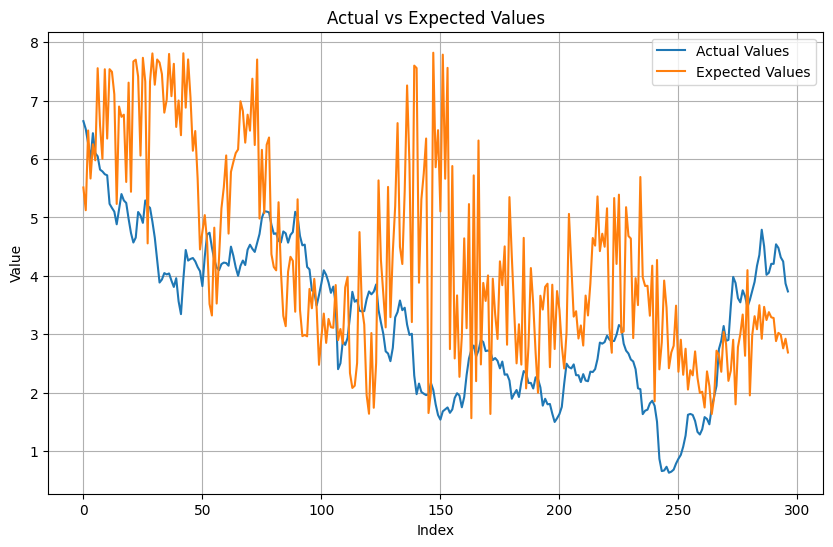

In [684]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 
plt.plot(actual_value_array, label='Actual Values') 
plt.plot(expected_value_array, label='Expected Values') 
plt.xlabel('Index') 
plt.ylabel('Value') 
plt.title('Actual vs Expected Values') 
plt.legend() 
plt.grid(True)
plt.show()

In [520]:
len(y)

418

In [ ]:
418-120

297

In [526]:
y["yield_5yr_ahead"][297+120]

3.9926666666666666